In [107]:
### 개발환경 세팅하기

# ▶ 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [108]:
# ▶ 한글 폰트 설정하기
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
import os
import pandas as pd
import numpy as np
import seaborn as sns

## **데이터 준비하기**
---

> **데이터 준비하기**

- 데이터 명세

| No. | 표준항목명             | 영문명                     | 설명                                                                           | 표현형식/단위  | 예시          |
|-----|------------------|---------------------|-----------------------------------------------------------------------------|-------------|-------------|
| 1   | 고객 ID             | CUST_ID               | 고객을 식별하기 위한 고유 ID                                                           | -           | C10001      |
| 2   | 잔액                | BALANCE               | 신용카드 계좌의 현재 잔액                                                               | N           | 40.9        |
| 3   | 잔액 업데이트 빈도     | BALANCE_FREQUENCY     | 잔액이 업데이트 되는 빈도                                                             | N           | 0.818       |
| 4   | 총 구매액            | PURCHASES             | 신용카드로 이루어진 총 구매액                                                          | N           | 95.4        |
| 5   | 일회성 구매액         | ONEOFF_PURCHASES      | 일회성으로 이루어진 구매액                                                             | N           | 0.0         |
| 6   | 할부 구매액           | INSTALLMENTS_PURCHASES | 할부로 이루어진 구매액                                                               | N           | 95.4        |
| 7   | 현금 서비스 금액       | CASH_ADVANCE          | 현금 서비스로 인출한 금액                                                              | N           | 0.0         |
| 8   | 구매 빈도             | PURCHASES_FREQUENCY    | 구매가 이루어진 빈도                                                                 | N           | 0.167       |
| 9   | 일회성 구매 빈도       | ONEOFF_PURCHASES_FREQUENCY | 일회성 구매가 이루어진 빈도                                                           | N           | 0.0         |
| 10  | 할부 구매 빈도         | PURCHASES_INSTALLMENTS_FREQUENCY | 할부 구매가 이루어진 빈도                                                         | N           | 0.083       |
| 11  | 현금 서비스 빈도       | CASH_ADVANCE_FREQUENCY  | 현금 서비스가 이루어진 빈도                                                           | N           | 0.0         |
| 12  | 현금 서비스 거래 횟수   | CASH_ADVANCE_TRX       | 현금 서비스 거래의 횟수                                                             | N           | 0           |
| 13  | 구매 횟수             | PURCHASES_TRX         | 총 구매 거래의 횟수                                                                | N           | 2           |
| 14  | 신용 한도             | CREDIT_LIMIT          | 신용카드의 신용 한도                                                                | N           | 1000.0      |
| 15  | 지불액               | PAYMENTS              | 신용카드 계좌에 지불한 총 금액                                                        | N           | 201.8       |
| 16  | 최소 지불액           | MINIMUM_PAYMENTS      | 신용카드 계좌의 최소 지불액                                                           | N           | 139.5       |
| 17  | 전액 지불 비율        | PRC_FULL_PAYMENT      | 신용카드 결제 금액 중 전액을 지불한 비율                                                  | N           | 0.0         |
| 18  | 카드 소지 기간         | TENURE                | 신용카드 계좌를 소지한 기간 (월)                                                       | N           | 12          |



In [110]:
# 데이터 불러오기
data = pd.read_csv("/content/drive/MyDrive/코드잇_DA_13기_이현재/미션 14/CC+GENERAL.csv")
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


## 데이터 파악 및 EDA (6문제)

### 문제1: 데이터셋 기본 정보 확인하기
- 데이터프레임의 기본 정보를 확인하고, 각 변수의 데이터 타입과 결측치 유무를 파악하세요.

In [111]:
# 데이터프레임의 기본 정보 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

- 데이터프레임의 총 행 수와 열 수, 각 변수의 데이터 타입 및 결측치 여부를 확인할 수 있습니다.
- MINIMUM_PAYMENTS와 CREDIT_LIMIT 변수에 결측치가 있습니다.

### 문제2: 기술 통계량 계산하기
각 변수의 기술 통계량을 계산하여 평균, 표준편차, 최소값, 최대값 등을 파악하세요.

In [112]:
# 각 변수의 기술 통계량 계산
data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### 문제3 : 중복값 확인하기
- 데이터프레임에서 중복값이 있는 지 확인해보세요. 있다면 중복값을 제거하세요.  

In [113]:
data_count = data.duplicated().sum()
print("중복된 행 개수: ",data_count)

중복된 행 개수:  0


### 문제4: 결측치 파악하기
- 데이터프레임에서 결측치가 존재하는 부분을 시각화해보세요.

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


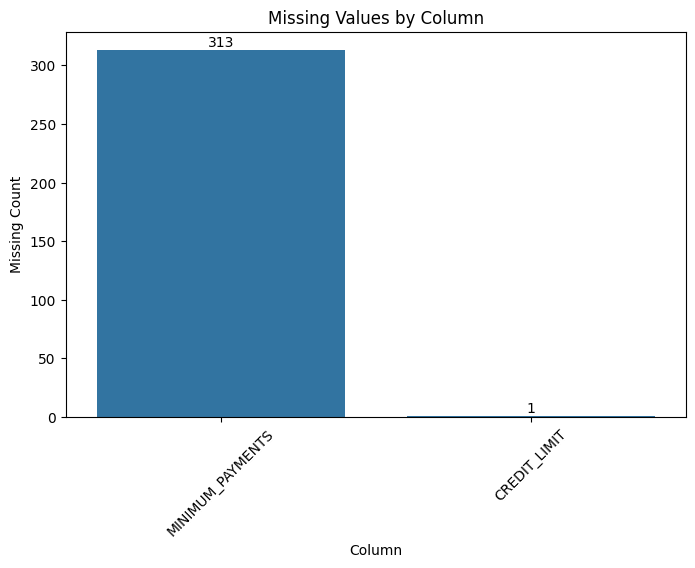

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 컬럼별 결측치 개수 확인
data_null = data.isnull().sum()
print(data_null)

# 2. 결측치가 있는 컬럼만 추출
missing_data = data_null[data_null > 0].sort_values(ascending=False)

# 3. 결측치 개수 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=missing_data.index, y=missing_data.values)

plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=45)

for i, v in enumerate(missing_data.values):
    plt.text(i, v + 3, str(v), ha='center')

plt.show()

### 문제5: 데이터 분포 시각화하기 - 히스토그램
각 변수의 데이터 분포를 히스토그램으로 시각화하세요.

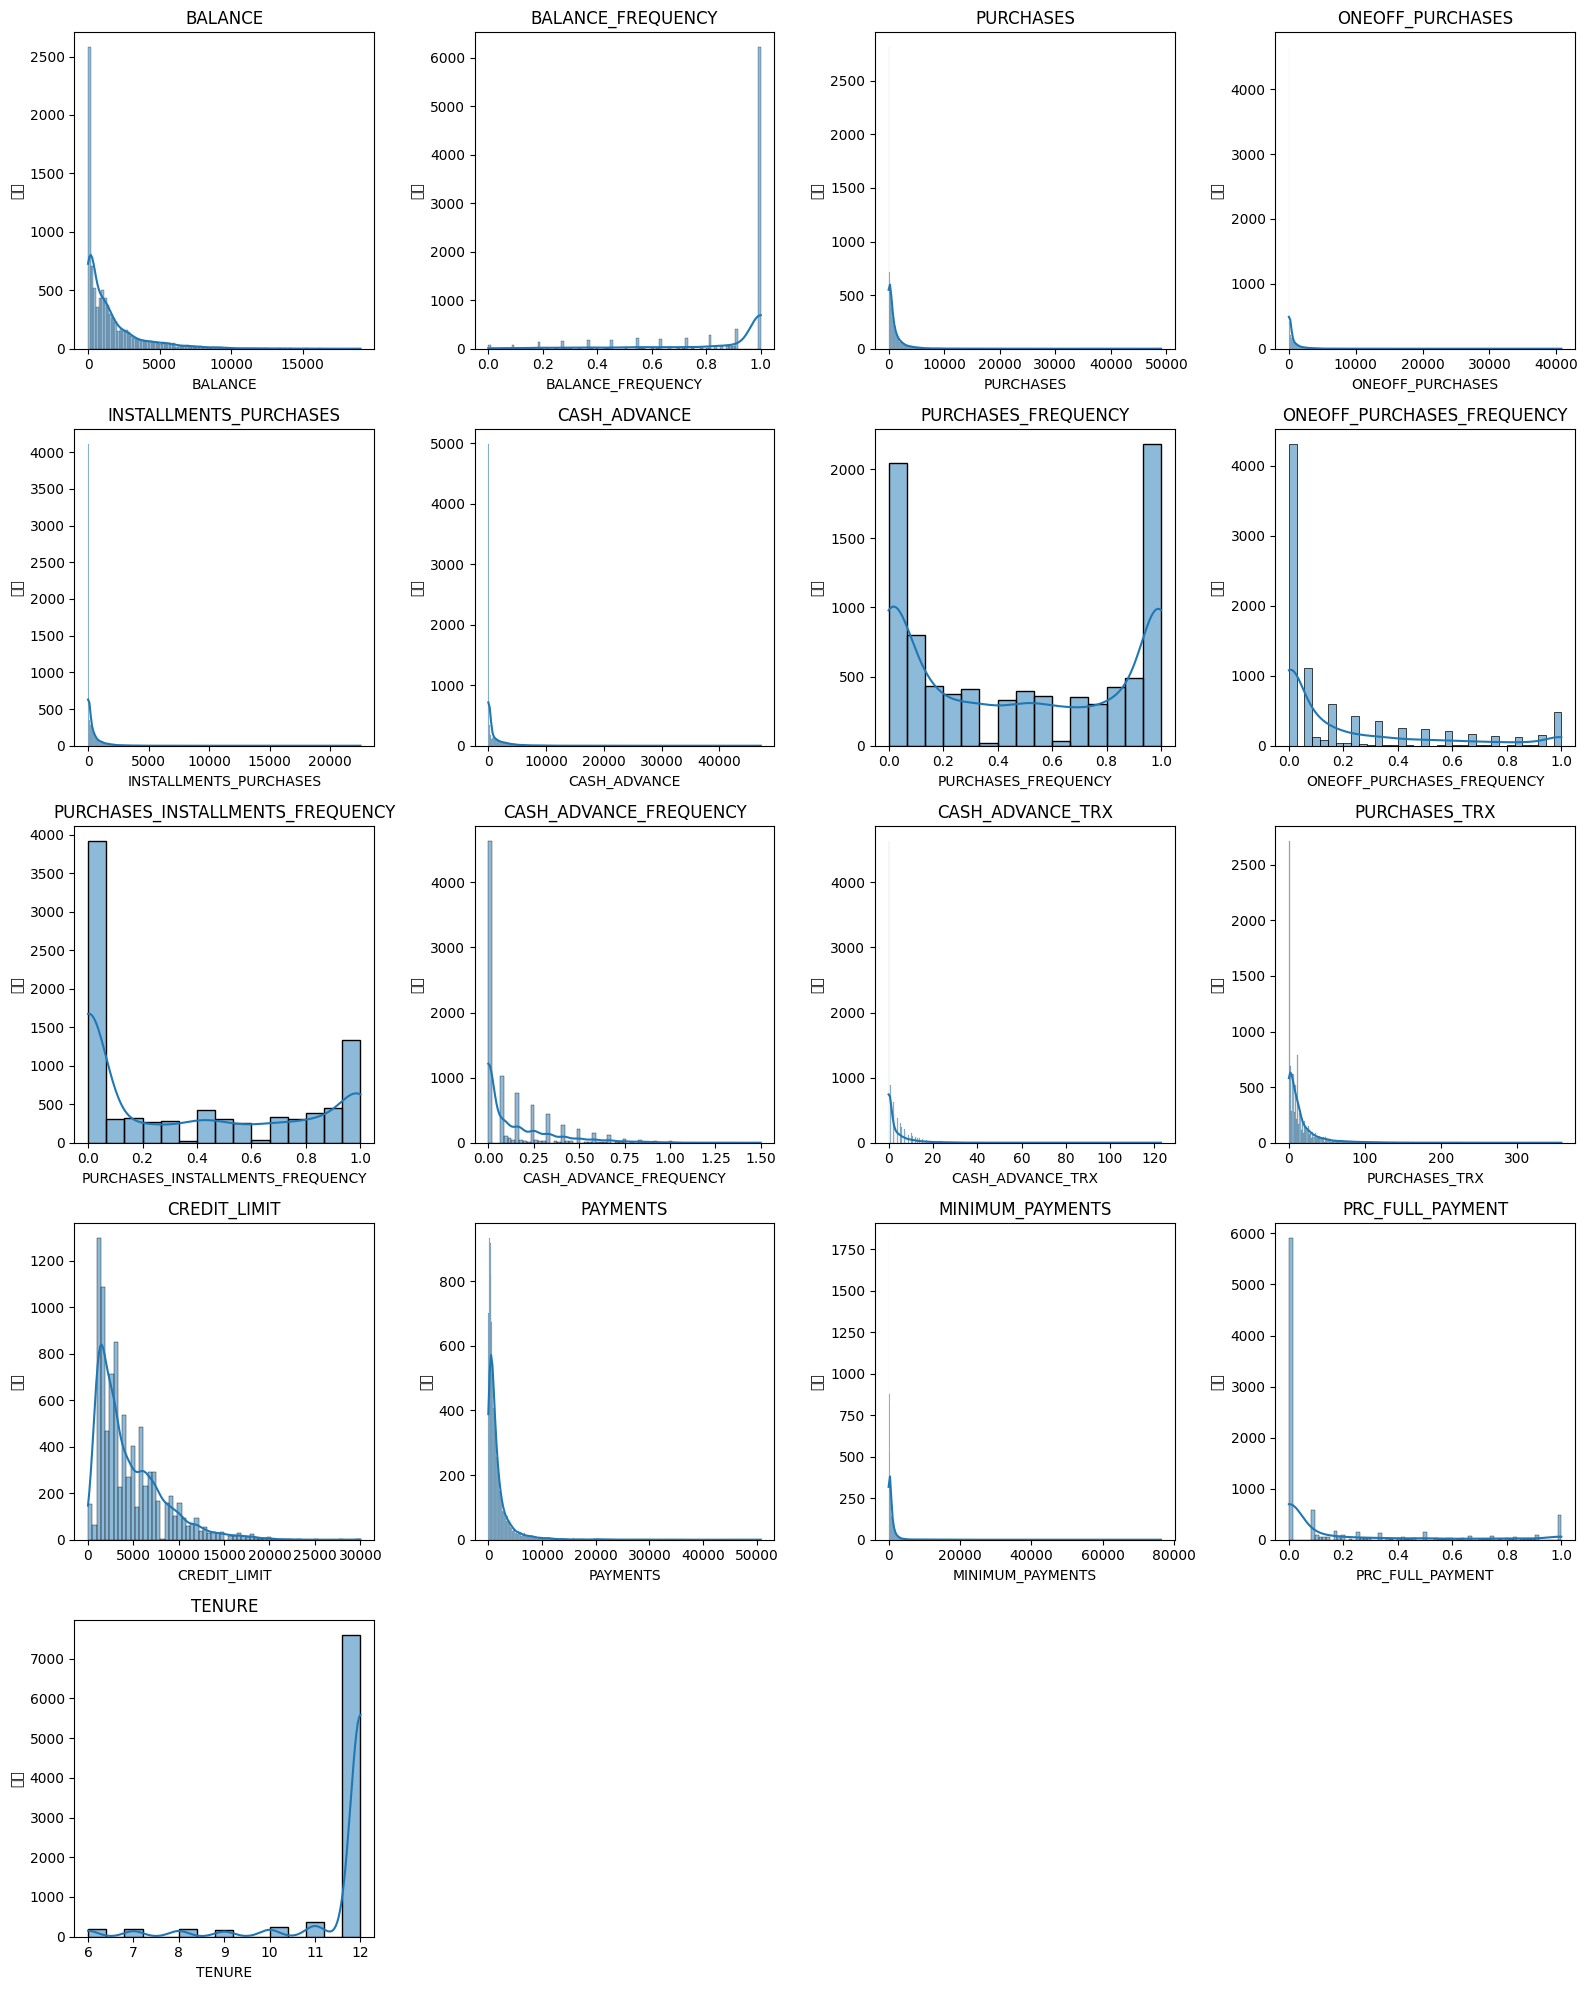

In [115]:
# 히스토그램 시각화
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자형 컬럼만 선택
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# 컬럼 개수에 맞게 subplot 크기 자동 설정
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('빈도')

plt.tight_layout()
plt.show()

### 문제6: 데이터의 이상치 파악하기
- 데이터의 이상치를 파악하세요. 이를 위해 각 변수의 분포를 상자 그림으로 시각화하세요.

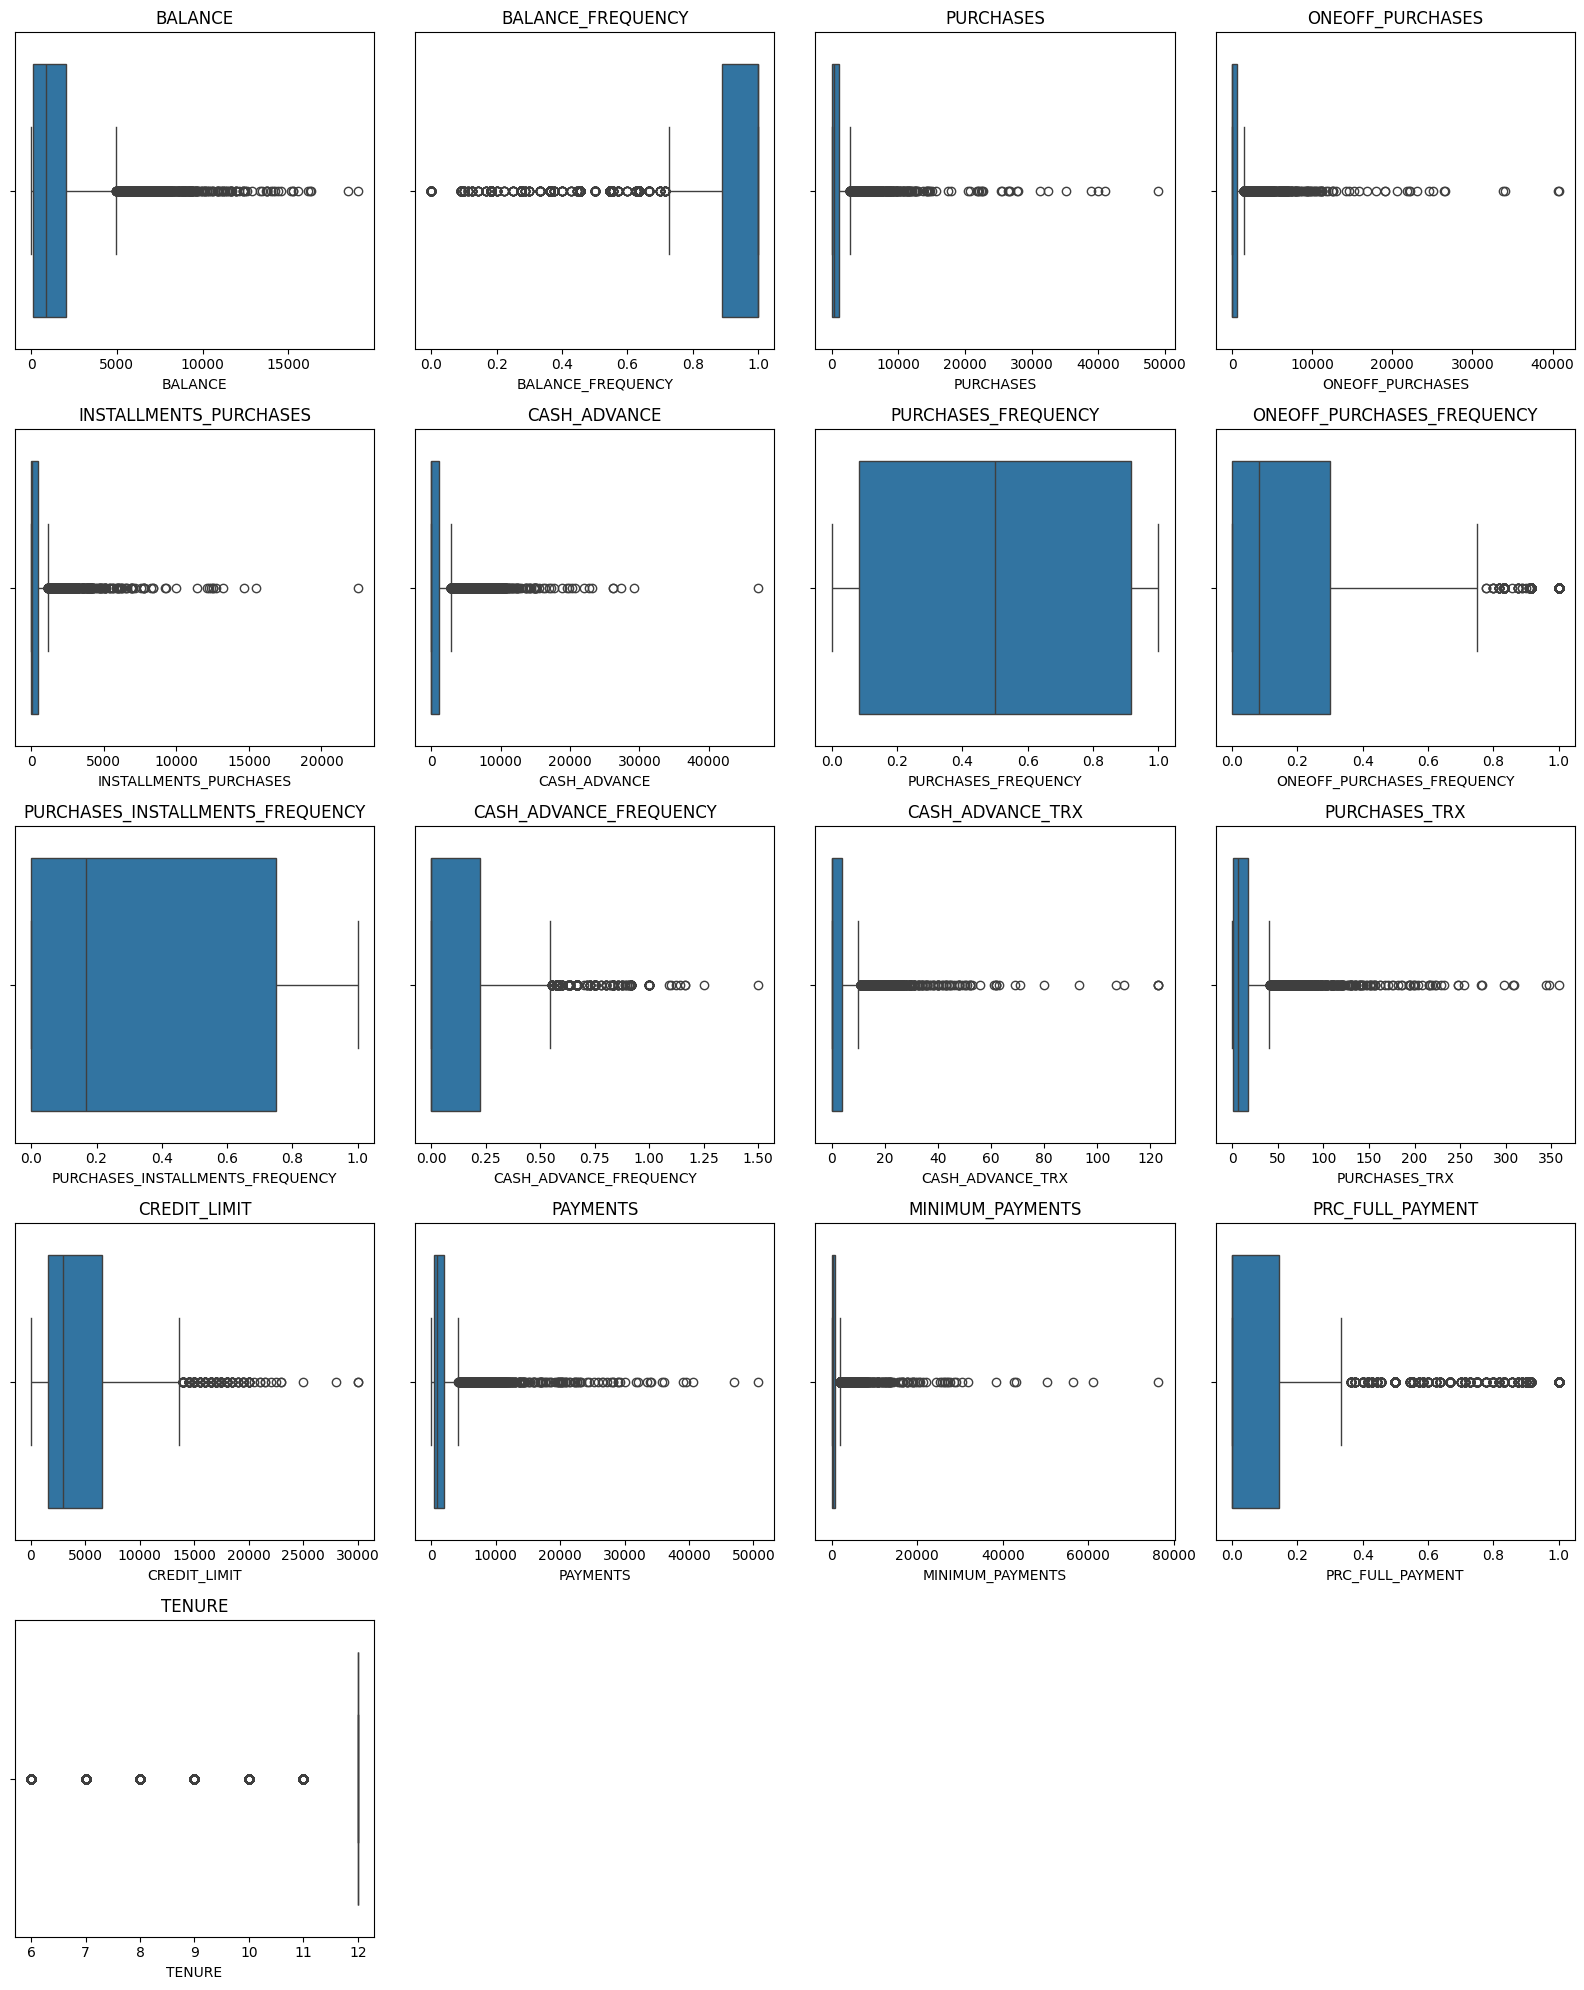

In [116]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자형 컬럼만 선택
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# subplot 자동 계산
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(16, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 데이터 전처리 (3문제)

### 문제7: 결측치 처리하기
-  변수의 결측치 수를 확인하고, 결측치가 존재하는 변수들을 적절한 방법으로 전처리하세요.

In [117]:
data_null = data.isnull().sum()
print(data_null)

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [118]:
print("데이터 결측치 삭제전 행수:", data.shape)
print('='*60)
data=data.dropna(subset=['CREDIT_LIMIT','MINIMUM_PAYMENTS'])
data=data.reset_index(drop=True)
print("데이터 결측치 삭제후 행수:", data.shape)

데이터 결측치 삭제전 행수: (8950, 18)
데이터 결측치 삭제후 행수: (8636, 18)


### 문제8: 이상치 처리하기

- 데이터에 이상치가 있는지 확인해보세요. 확인 후, 전처리가 필요하다면 진행해주세요.

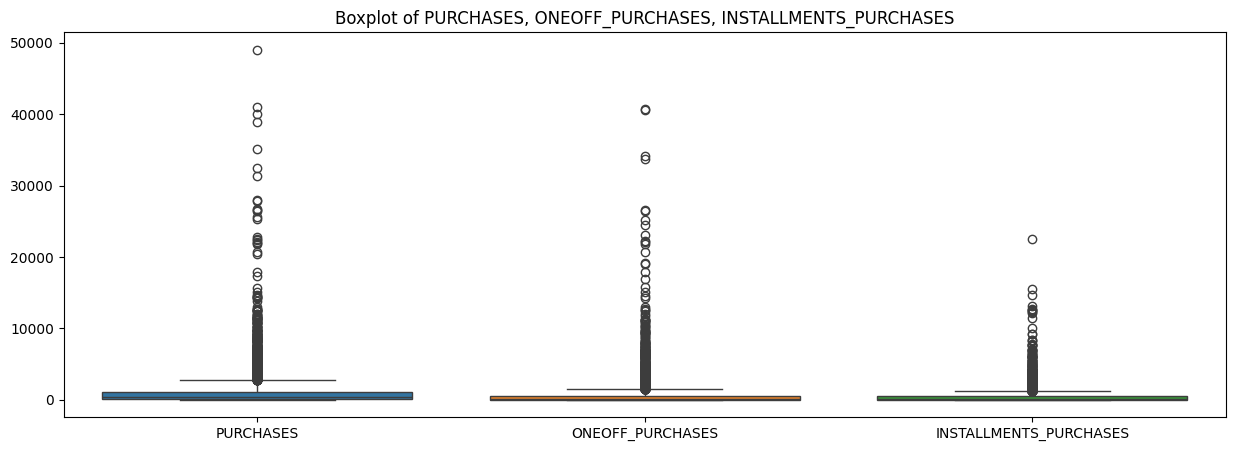

In [119]:
# 이상치 제거 전 시각화
import matplotlib.pyplot as plt
import seaborn as sns

outlier_cols=['PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES']

plt.figure(figsize=(15,5))

sns.boxplot(data=data[outlier_cols])

plt.title('Boxplot of PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES')
plt.show()

In [120]:
# 이상치 제거 (전처리 진행)

outlier_cols=['PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES']

for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR =Q3-Q1

    lower_bound=Q1 - (1.5 * IQR)
    upper_bound=Q3 + (1.5 * IQR)

    data[col] = data[col].clip(lower=lower_bound,upper=upper_bound)

print("이상치 처리 완료")
data[outlier_cols].describe()

이상치 처리 완료


,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
count,8636.000000,8636.000000,8636.000000
mean,758.477729,365.932345,305.242727
std,902.915222,527.730351,407.479840
min,0.000000,0.000000,0.000000
25%,43.367500,0.000000,0.000000
50%,375.405000,44.995000,94.785000
75%,1145.980000,599.100000,484.147500
max,2799.898750,1497.750000,1210.368750


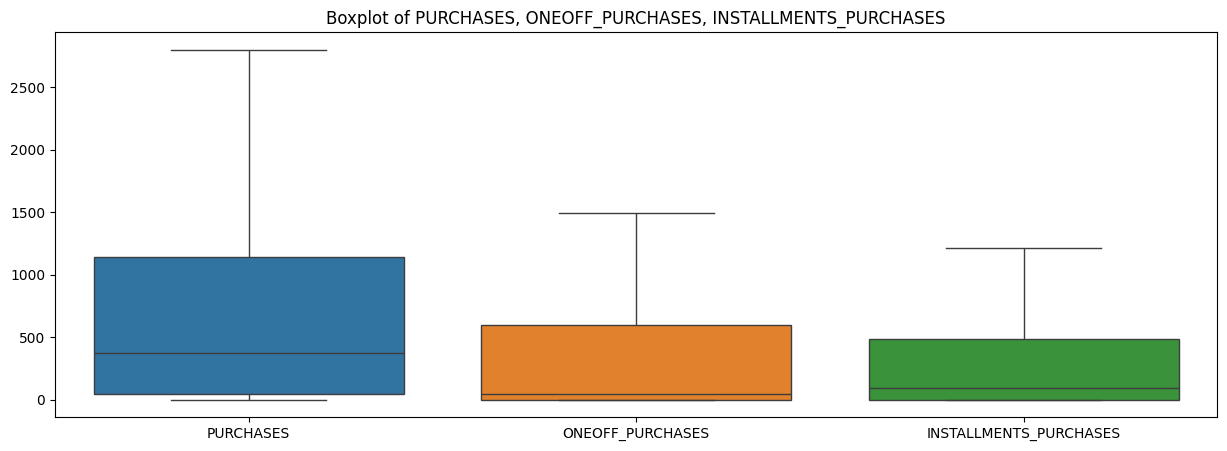

In [121]:
# 이상치 제거 후 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

sns.boxplot(data=data[outlier_cols])

plt.title('Boxplot of PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES')
plt.show()

### 문제9: 데이터 스케일링하기
- 각 변수의 데이터를 표준화 혹은 정규화하세요.

In [122]:
from sklearn.preprocessing import StandardScaler

numeric_cols = data.select_dtypes(include=['int64','float64']).columns

sc = StandardScaler()

data[numeric_cols]=sc.fit_transform(data[numeric_cols])

#data[numeric_cols].head()
print(data[numeric_cols].mean())
print('*'*60)
print(data[numeric_cols].std(ddof=0))

BALANCE                             0.000000e+00
BALANCE_FREQUENCY                  -3.422716e-16
PURCHASES                          -6.582147e-17
ONEOFF_PURCHASES                    1.020233e-16
INSTALLMENTS_PURCHASES              2.929055e-16
CASH_ADVANCE                       -4.278395e-17
PURCHASES_FREQUENCY                 6.582147e-18
ONEOFF_PURCHASES_FREQUENCY         -3.291073e-18
PURCHASES_INSTALLMENTS_FREQUENCY    8.227683e-18
CASH_ADVANCE_FREQUENCY              2.468305e-17
CASH_ADVANCE_TRX                    2.715136e-17
PURCHASES_TRX                      -1.151876e-17
CREDIT_LIMIT                        1.118965e-16
PAYMENTS                           -2.632859e-17
MINIMUM_PAYMENTS                   -4.442949e-17
PRC_FULL_PAYMENT                    5.923932e-17
TENURE                              9.215005e-17
dtype: float64
************************************************************
BALANCE                             1.0
BALANCE_FREQUENCY                   1.0
PURCHASES  

- 표준화는 데이터의 평균을 0, 표준편차를 1로 맞추어 변환합니다.
- 정규화는 데이터 값을 0과 1 사이로 변환합니다.
- 표준화와 정규화는 모델 학습의 성능을 향상시킬 수 있습니다.

이후 분석은 표준화된 데이터를 바탕으로 진행하겠습니다.

## 클러스터 분석 (11문제)

###문제10: K-means 클러스터링 모델 학습
- K-means 알고리즘을 사용하여 클러스터링 모델을 학습하세요. 클러스터의 수는 3로 설정하세요.

In [123]:
from sklearn.cluster import KMeans

X = data.drop(columns=['CUST_ID'])

kmeans=KMeans(n_clusters=3,random_state=42)
data['Cluster_Kmeans']=kmeans.fit_predict(X)
data['Cluster_Kmeans'].value_counts()

,count
Cluster_Kmeans,
2,5154
1,2055
0,1427


### 문제11 : 클러스터링 결과 시각화 (2D)
- 두 개의 주요 변수(BALANCE, PURCHASES)를 사용하여 클러스터링 결과를 2D로 시각화하세요.

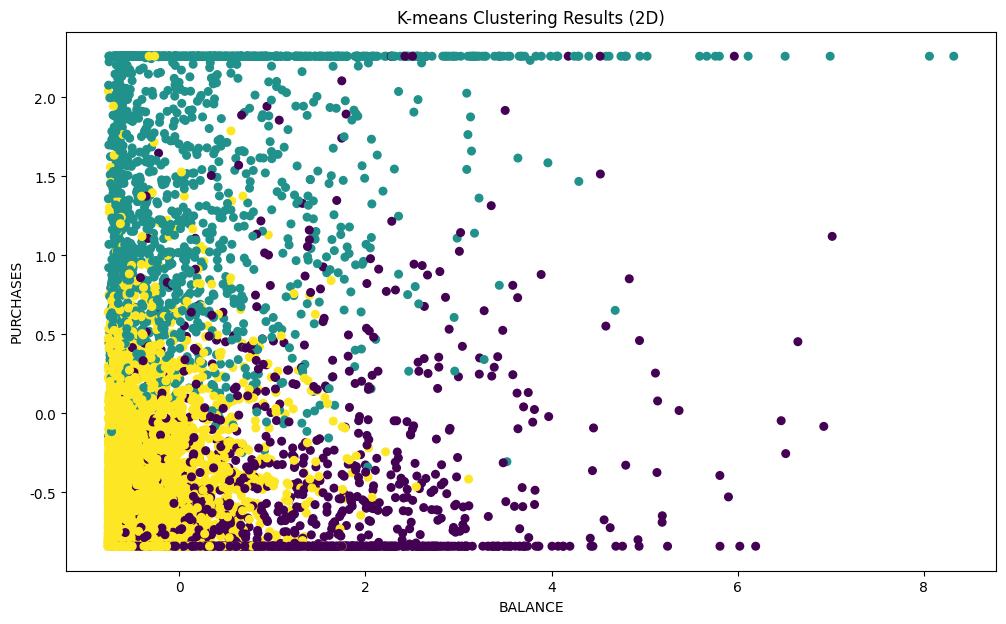

In [124]:
plt.figure(figsize=(12,7))

plt.scatter(
    data['BALANCE'],
    data['PURCHASES'],
    c=data['Cluster_Kmeans'],
    cmap='viridis',
    s=30
)
plt.title('K-means Clustering Results (2D)')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')

plt.show()

### 문제12: 클러스터 수 결정 (Elbow Method)
- Elbow Method를 사용하여 최적의 클러스터 수를 결정하세요.

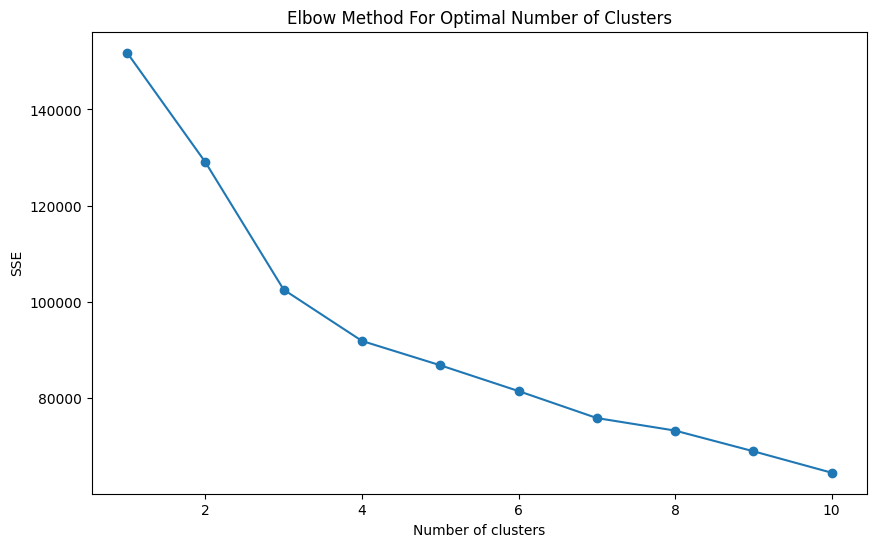

In [125]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X= data.drop(columns=['CUST_ID','Cluster_KMeans'], errors='ignore')

sse=[]

for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

### 문제13 : 결과를 해석해보세요.

- 아래는 클러스터의 수를 5로 진행하고, 2가지 변수(BALANCE, PURCHASES)로 시각화를 한 결과입니다.
- 결과를 보고 추가 분석을 진행하여 인사이트를 발견해보세요. 클러스터 별로 어떤 차이가 있나요?

In [126]:
from sklearn.cluster import KMeans
data1=data.copy()
X = data1.drop(columns=['CUST_ID','Cluster_Kmeans'],errors='ignore')

kmeans=KMeans(n_clusters=5,random_state=42)
data1['Cluster_Kmeans5']=kmeans.fit_predict(X)
data1['Cluster_Kmeans5'].value_counts()

,count
Cluster_Kmeans5,
3,3023
2,2071
1,1532
4,1162
0,848


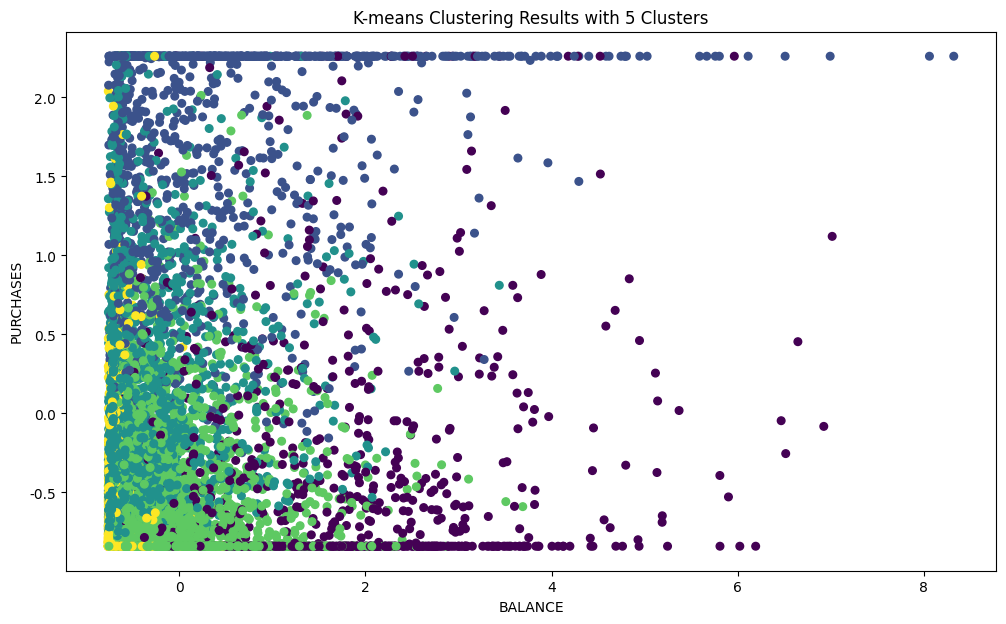

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    data1['BALANCE'],
    data1['PURCHASES'],
    c=data1['Cluster_Kmeans5'],
    cmap='viridis',
    s=30
)

plt.title('K-means Clustering Results with 5 Clusters')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')

plt.show()

In [128]:
import pandas as pd

original_data = pd.DataFrame(
    sc.inverse_transform(data1[numeric_cols]),
    columns=numeric_cols,
    index=data1.index
)

original_data['Cluster_Kmeans5'] = data1['Cluster_Kmeans5']

analysis_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'PRC_FULL_PAYMENT'
]

cluster_count = original_data['Cluster_Kmeans5'].value_counts().sort_index()
cluster_ratio = original_data['Cluster_Kmeans5'].value_counts(normalize=True).sort_index() * 100

cluster_summary = original_data.groupby('Cluster_Kmeans5')[analysis_cols].mean().round(2)

cluster_summary.insert(0, '고객수', cluster_count)
cluster_summary.insert(1, '비율(%)', cluster_ratio.round(2))

cluster_summary

,고객수,비율(%),BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
Cluster_Kmeans5,,,,,,,,,,,
0,848,9.82,5072.51,453.47,254.12,160.12,5359.09,8240.81,4166.72,2264.52,0.04
1,1532,17.74,2030.25,2254.74,1254.36,660.93,417.11,7135.45,3524.84,893.00,0.27
2,2071,23.98,744.71,808.84,122.87,600.68,244.82,3278.05,1019.43,769.55,0.27
3,3023,35.00,1560.48,216.71,177.65,36.01,828.88,3290.07,976.30,794.78,0.02
4,1162,13.46,134.86,328.05,199.26,116.08,335.16,3785.17,1217.50,154.40,0.27


In [129]:
print("BALANCE가 가장 높은 클러스터:", cluster_summary['BALANCE'].idxmax())
print("PURCHASES가 가장 높은 클러스터:", cluster_summary['PURCHASES'].idxmax())
print("ONEOFF_PURCHASES가 가장 높은 클러스터:", cluster_summary['ONEOFF_PURCHASES'].idxmax())
print("INSTALLMENTS_PURCHASES가 가장 높은 클러스터:", cluster_summary['INSTALLMENTS_PURCHASES'].idxmax())
print("CASH_ADVANCE가 가장 높은 클러스터:", cluster_summary['CASH_ADVANCE'].idxmax())
print("CREDIT_LIMIT가 가장 높은 클러스터:", cluster_summary['CREDIT_LIMIT'].idxmax())
print("PRC_FULL_PAYMENT가 가장 높은 클러스터:", cluster_summary['PRC_FULL_PAYMENT'].idxmax())

BALANCE가 가장 높은 클러스터: 0
PURCHASES가 가장 높은 클러스터: 1
ONEOFF_PURCHASES가 가장 높은 클러스터: 1
INSTALLMENTS_PURCHASES가 가장 높은 클러스터: 1
CASH_ADVANCE가 가장 높은 클러스터: 0
CREDIT_LIMIT가 가장 높은 클러스터: 0
PRC_FULL_PAYMENT가 가장 높은 클러스터: 1


K-means 클러스터 수를 5로 설정하여 고객을 5개의 군집으로 세분화하였다.
클러스터별 평균값을 비교한 결과, 각 고객군은 BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PRC_FULL_PAYMENT 등에서 뚜렷한 차이를 보였다.

클러스터 0은 전체 고객의 약 9.82%를 차지하며, BALANCE, CASH_ADVANCE, CREDIT_LIMIT, MINIMUM_PAYMENTS가 가장 높은 집단이다.
이는 신용한도는 높지만 카드 잔액과 현금서비스 이용 금액도 큰 고객군으로, 자금 이용 규모가 크고 부채 부담이 상대적으로 높은 고객군으로 해석할 수 있다.

클러스터 1은 전체 고객의 약 17.74%를 차지하며, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PAYMENTS, PRC_FULL_PAYMENT가 가장 높은 집단이다.
즉, 카드 구매 활동이 매우 활발하고 결제도 비교적 잘 이루어지는 핵심 소비 고객군으로 볼 수 있다.

클러스터 2는 전체 고객의 약 23.98%를 차지하며, BALANCE는 낮은 편이고 PURCHASES와 INSTALLMENTS_PURCHASES가 중간 수준이다.
이는 일시불보다는 할부 구매를 일정 수준 이용하는 일반 소비 고객군으로 해석할 수 있다.

클러스터 3은 전체 고객의 약 35.0%로 가장 큰 비중을 차지한다. PURCHASES와 PRC_FULL_PAYMENT가 낮고 BALANCE와 CASH_ADVANCE는 일정 수준 존재한다.
따라서 카드 구매 활동은 낮지만 잔액을 보유하거나 현금서비스를 일부 이용하는 소극적 이용 고객군으로 볼 수 있다.

클러스터 4는 전체 고객의 약 13.46%를 차지하며, BALANCE와 MINIMUM_PAYMENTS가 가장 낮고 PRC_FULL_PAYMENT는 비교적 높은 편이다.
이는 카드 이용 규모는 작지만 결제 부담이 낮고 관리가 안정적인 저위험 고객군으로 해석할 수 있다.

종합하면, 클러스터링 결과를 통해 고객을 고위험 자금이용 고객, 핵심 소비 고객, 일반 할부 이용 고객, 소극적 이용 고객, 저위험 소액 이용 고객으로 구분할 수 있었다.
이러한 결과는 고객군별 맞춤형 마케팅 전략과 리스크 관리 전략을 수립하는 데 활용할 수 있다.


### 문제14: 계층적 클러스터링 모델 학습 및 덴드로그램 시각화
- 계층적 클러스터링을 scipy를 사용하여 모델을 학습하고, 덴드로그램을 시각화하세요.

In [130]:
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
import matplotlib.pyplot as plt
drop_cols = ['CUST_ID', 'Cluster_Kmeans', 'Cluster_Kmeans5', 'Cluster_KMeans', 'Cluster_KMeans_5']

scaled_df = data.drop(columns=drop_cols, errors='ignore')
scaled_df = scaled_df.select_dtypes(include=['int64', 'float64'])

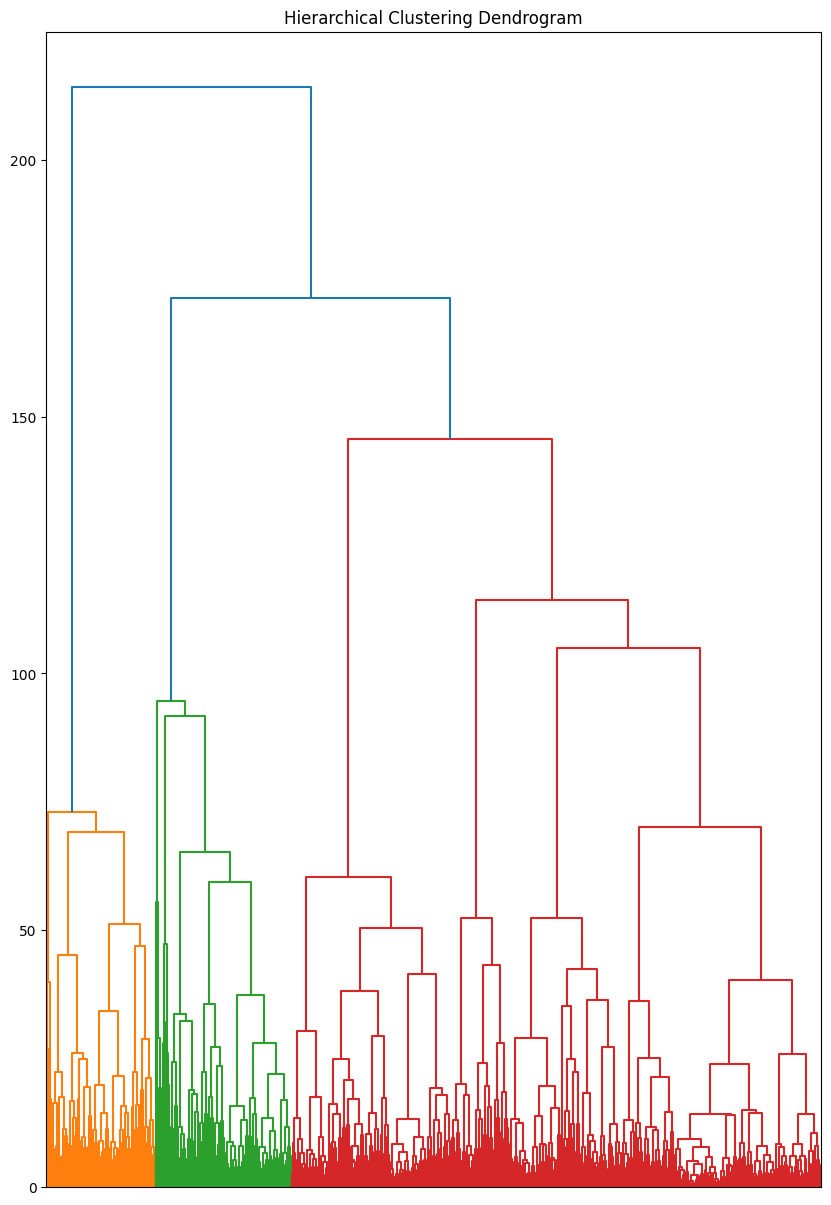

In [131]:
model = linkage(scaled_df,method='ward')
plt.figure(figsize=(10,15))
dendrogram(model,no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

### 문제15: DBSCAN 클러스터링 모델 학습
- DBSCAN 알고리즘을 사용하여 클러스터링 모델을 학습하고, 결과를 얻으세요.

In [132]:
from sklearn.cluster import DBSCAN

X_dbscan = data.drop(columns=['CUST_ID'],errors='ignore')
X_dbscan = X_dbscan[[col for col in X_dbscan.columns if 'Cluster' not in col]]
X_dbscan = X_dbscan.select_dtypes(include=['int64', 'float64'])


In [133]:
dbscan=DBSCAN(eps=2,min_samples=5)
data['Cluster_DBSCAN']= dbscan.fit_predict(X_dbscan)
data['Cluster_DBSCAN'].value_counts()

,count
Cluster_DBSCAN,
0,8003
-1,624
1,5
2,4


### 문제16: DBSCAN 클러스터링 모델 학습 (매개변수 조정)
- DBSCAN의 eps와 min_samples 값을 조정하여, 클러스터링 결과가 개선되도록 하세요.

In [134]:
# DBSCAN 모델 학습 (매개변수 조정)
from sklearn.cluster import DBSCAN

X_dbscan = data.drop(columns=['CUST_ID'],errors='ignore')
X_dbscan = X_dbscan[[col for col in X_dbscan.columns if 'Cluster' not in col]]
X_dbscan = X_dbscan.select_dtypes(include=['int64', 'float64'])

dbscan_adj=DBSCAN(eps=1,min_samples=4)
data['Cluster_dbscan_adjusted']=dbscan_adj.fit_predict(X_dbscan)
data['Cluster_dbscan_adjusted'].value_counts()

,count
Cluster_dbscan_adjusted,
0,4968
-1,3413
3,21
9,14
7,14
13,11
18,11
2,9
21,9


### 문제17: 클러스터링 결과 시각화 및 노이즈 탐지
- DBSCAN 결과를 시각화하고, 노이즈 데이터를 탐지하세요.

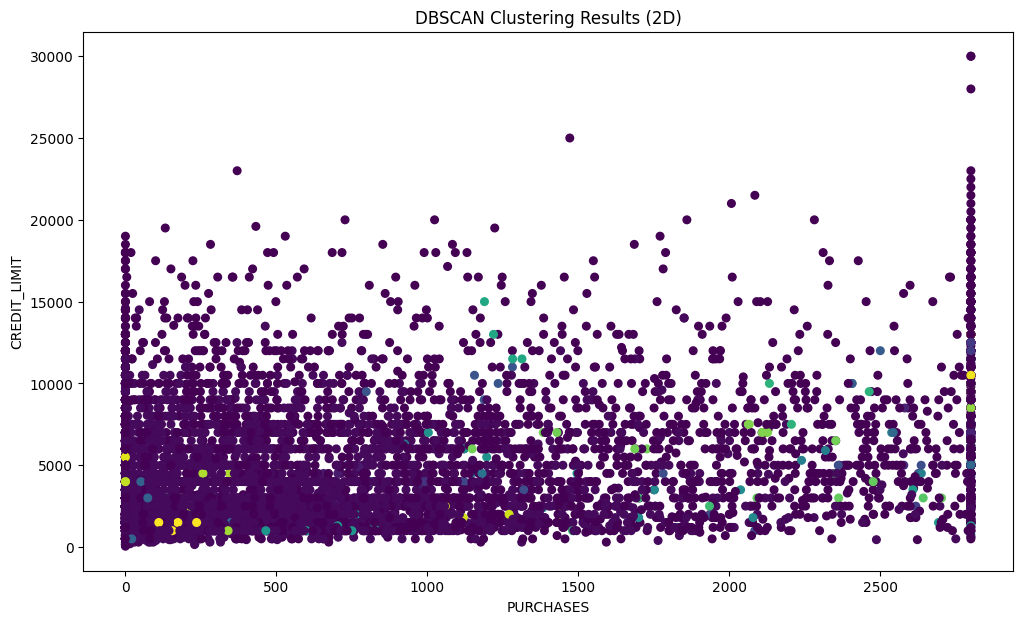

Number of noise points: 3413


In [135]:
# DBSCAN 결과 시각화 (최적 매개변수 사용 후)
import pandas as pd
import matplotlib.pyplot as plt

# 스케일링된 데이터를 원래 값으로 복원
try:
    plot_data = original_data.copy()
except NameError:
    try:
        scaler_obj = scaler
    except NameError:
        scaler_obj = sc

    plot_data = pd.DataFrame(
        scaler_obj.inverse_transform(data[numeric_cols]),
        columns=numeric_cols,
        index=data.index
    )

# DBSCAN 결과 컬럼 추가
plot_data['Cluster_dbscan_adjusted'] = data['Cluster_dbscan_adjusted']

# 시각화
plt.figure(figsize=(12, 7))

plt.scatter(
    plot_data['PURCHASES'],
    plot_data['CREDIT_LIMIT'],
    c=plot_data['Cluster_dbscan_adjusted'],
    cmap='viridis',
    s=30
)

plt.title('DBSCAN Clustering Results (2D)')
plt.xlabel('PURCHASES')
plt.ylabel('CREDIT_LIMIT')

plt.show()

# 노이즈 데이터 개수 출력
noise_count = (plot_data['Cluster_dbscan_adjusted'] == -1).sum()
print("Number of noise points:", noise_count)

In [136]:
# 노이즈 데이터 개수 확인
noise_count = (data['Cluster_dbscan_adjusted'] == -1).sum()

print("Number of noise points:", noise_count)

Number of noise points: 3413


### 문제18: GMM 클러스터링 모델 학습
- Gaussian Mixture Model을 사용하여 클러스터링 모델을 학습하고, 결과를 얻으세요. 클러스터의 수는 3으로 설정하세요.

In [137]:
from sklearn.mixture import GaussianMixture

X_gmm = data.drop(columns=['CUST_ID'], errors='ignore')
X_gmm = X_gmm[[col for col in X_gmm.columns if 'cluster' not in col.lower()]]
X_gmm = X_gmm.select_dtypes(include=['int64', 'float64'])

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

data['Cluster_GMM'] = gmm.fit_predict(X_gmm)
data['Cluster_GMM'].value_counts()

,count
Cluster_GMM,
2,3092
1,2961
0,2583


### 문제19: 클러스터링 결과 시각화 및 클러스터 확률 해석
- GMM 결과를 시각화하고, 각 데이터 포인트의 클러스터 소속 확률을 확인하세요.

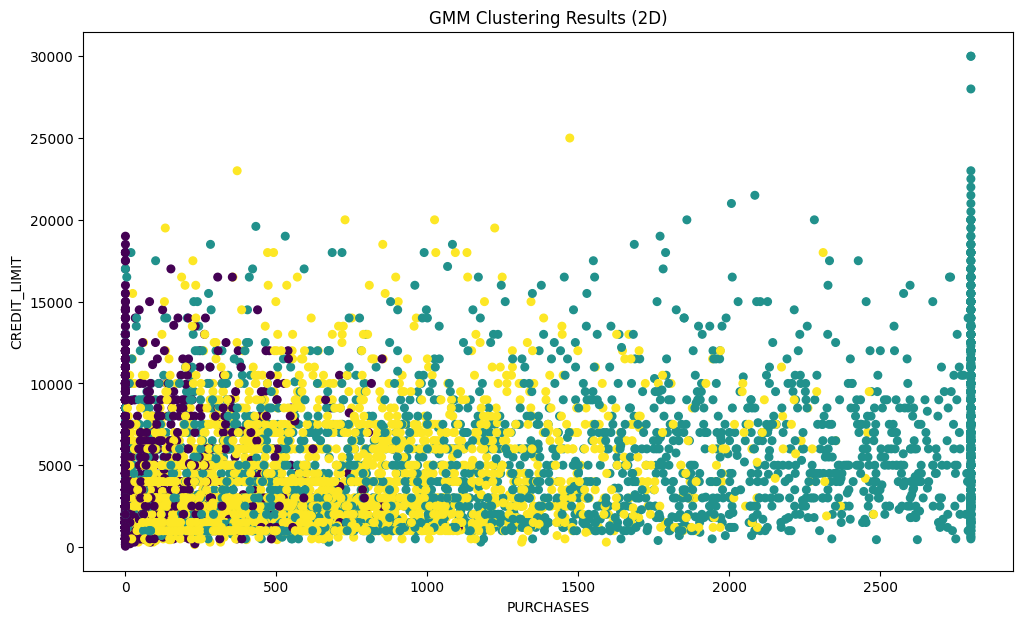

,Cluster_gmm,Cluster_probabilities
0,2,1.000000
1,0,1.000000
2,2,1.000000
3,0,0.994647
4,1,1.000000


In [138]:
# GMM 결과 시각화 및 클러스터 소속 확률 확인

from sklearn.mixture import GaussianMixture
import pandas as pd
import matplotlib.pyplot as plt

# GMM 학습용 데이터 준비
X_gmm = data.drop(columns=['CUST_ID'], errors='ignore')

# 기존 클러스터 결과 컬럼 제거
X_gmm = X_gmm[[col for col in X_gmm.columns if 'cluster' not in col.lower()]]

# 숫자형 데이터만 사용
X_gmm = X_gmm.select_dtypes(include=['int64', 'float64'])

# GMM 모델 학습
gmm = GaussianMixture(n_components=3, random_state=42)

# 클러스터 예측
data['Cluster_gmm'] = gmm.fit_predict(X_gmm)

# 각 데이터가 각 클러스터에 속할 확률 계산
probabilities = gmm.predict_proba(X_gmm)

# 가장 높은 소속 확률 저장
data['Cluster_probabilities'] = probabilities.max(axis=1)

# 시각화를 위해 원래 값으로 복원
try:
    scaler_obj = scaler
except NameError:
    scaler_obj = sc

plot_data = pd.DataFrame(
    scaler_obj.inverse_transform(data[numeric_cols]),
    columns=numeric_cols,
    index=data.index
)

plot_data['Cluster_gmm'] = data['Cluster_gmm']
plot_data['Cluster_probabilities'] = data['Cluster_probabilities']

# GMM 결과 2D 시각화
plt.figure(figsize=(12, 7))

plt.scatter(
    plot_data['PURCHASES'],
    plot_data['CREDIT_LIMIT'],
    c=plot_data['Cluster_gmm'],
    cmap='viridis',
    s=30
)

plt.title('GMM Clustering Results (2D)')
plt.xlabel('PURCHASES')
plt.ylabel('CREDIT_LIMIT')

plt.show()

# 클러스터 소속 확률 확인
data[['Cluster_gmm', 'Cluster_probabilities']].head()

### 문제20: 클러스터링 결과 해석 및 비교
- K-means, 계층적 클러스터링, DBSCAN, GMM의 클러스터링 결과를 비교해보세요.
- 각 방법의 장단점, 특징도 고려해서 결과 분석을 진행해보세요.

In [139]:
print("""
이번 분석에서는 K-means, 계층적 클러스터링, DBSCAN, GMM을 활용하여 고객 데이터를 군집화하고 결과를 비교하였다. 각 알고리즘은 군집을 형성하는 기준이 다르기 때문에 동일한 데이터라도 서로 다른 방식으로 고객군을 구분하였다.

먼저 K-means는 클러스터 수를 3개로 설정하여 고객을 분류하였다. 분석 결과 클러스터 2가 5154명으로 가장 큰 비중을 차지했고, 클러스터 1은 2055명, 클러스터 0은 1427명으로 분류되었다. K-means는 사전에 지정한 클러스터 수에 따라 데이터를 빠르게 분류할 수 있다는 장점이 있다. 또한 BALANCE와 PURCHASES 기준 2D 시각화에서도 고객들이 비교적 명확하게 색상별로 나뉘는 모습을 확인할 수 있었다. 다만 K-means는 클러스터 수를 미리 정해야 하며, 구형 또는 중심 기반 군집 구조를 가정하기 때문에 복잡한 형태의 데이터 분포나 이상치에는 민감할 수 있다.

추가로 K-means의 클러스터 수를 5개로 설정하여 고객군을 더 세분화하였다. 클러스터별 평균값을 비교한 결과, 클러스터 0은 BALANCE, CASH_ADVANCE, CREDIT_LIMIT가 가장 높아 신용한도와 현금서비스 이용 규모가 큰 고객군으로 해석되었다. 클러스터 1은 PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PAYMENTS, PRC_FULL_PAYMENT가 가장 높아 카드 구매 활동이 활발하고 결제도 비교적 잘 이루어지는 핵심 소비 고객군으로 볼 수 있었다. 클러스터 3은 전체 고객의 35.0%로 가장 큰 비중을 차지했지만 PURCHASES와 PRC_FULL_PAYMENT가 낮아 소극적 카드 이용 고객군으로 해석되었다. 이처럼 K-means는 고객군별 평균 특성을 비교하기에 직관적이고, 마케팅 전략 수립에 활용하기 좋은 결과를 제공하였다.

계층적 클러스터링은 Ward 방식으로 덴드로그램을 생성하여 데이터 간 유사도와 군집 병합 구조를 확인하였다. 계층적 클러스터링의 장점은 클러스터 수를 처음부터 고정하지 않고, 덴드로그램을 통해 데이터가 어떤 순서로 묶이는지 시각적으로 확인할 수 있다는 점이다. 따라서 전체 고객 데이터가 어떤 계층적 구조를 가지는지 탐색하는 데 유용하다. 그러나 데이터 수가 많아질수록 계산량이 커지고, 덴드로그램이 복잡해져 해석이 어려워질 수 있다. 이번 데이터처럼 고객 수가 많은 경우에는 전체 데이터를 직접 해석하기보다는 군집 구조를 참고하는 용도로 활용하는 것이 적절하다.

DBSCAN은 밀도 기반 클러스터링 방법으로, K-means와 달리 클러스터 수를 미리 지정하지 않아도 된다. 분석 결과 하나의 큰 클러스터와 다수의 작은 클러스터, 그리고 많은 노이즈 데이터가 생성되었다. 노이즈 데이터는 -1로 표시되며, 현재 노트북 출력 기준으로 약 3413개의 데이터가 노이즈로 분류되었다. 이는 전체 고객 중 상당수가 일반적인 밀집 군집에 포함되지 않는 특이한 소비 패턴을 보였다는 의미로 해석할 수 있다. DBSCAN의 장점은 이상치와 노이즈 탐지에 강하고, 불규칙한 형태의 군집도 탐지할 수 있다는 점이다. 반면 eps와 min_samples 값에 따라 결과가 크게 달라지며, 고차원 데이터에서는 적절한 밀도 기준을 정하기 어렵다는 단점이 있다.

GMM은 Gaussian Mixture Model을 사용하여 고객 데이터를 3개의 확률 기반 군집으로 분류하였다. GMM은 각 데이터가 특정 클러스터에 속할 확률을 함께 계산한다는 점에서 K-means보다 유연하다. 분석 결과 각 데이터는 Cluster_gmm으로 분류되었고, Cluster_probabilities 값을 통해 각 고객이 해당 클러스터에 얼마나 높은 확률로 속하는지 확인할 수 있었다. 일부 데이터의 소속 확률이 1.0에 가깝게 나타났는데, 이는 해당 고객이 특정 군집에 매우 명확하게 속한다는 의미이다. GMM은 군집 간 경계가 부드럽고 확률적으로 해석할 수 있다는 장점이 있지만, 데이터가 여러 개의 정규분포가 섞여 있다는 가정을 전제로 하기 때문에 실제 데이터 분포가 이 가정과 다르면 해석에 주의가 필요하다.

종합적으로 보면, K-means는 고객을 명확한 개수의 군집으로 빠르게 나누고 클러스터별 평균 특성을 비교하는 데 가장 적합하였다. 계층적 클러스터링은 고객군이 어떻게 단계적으로 묶이는지 구조를 파악하는 데 유용하였다. DBSCAN은 일반적인 고객군에서 벗어난 노이즈 고객을 탐지하는 데 강점이 있었지만, 많은 데이터가 노이즈로 분류되어 마케팅 세분화보다는 이상 고객 탐지에 더 적합하였다. GMM은 각 고객의 클러스터 소속 확률을 제공하여 군집 배정의 확신도를 함께 해석할 수 있다는 장점이 있었다.

따라서 이번 고객 데이터에서는 마케팅 전략 수립과 고객군 해석을 목적으로 할 경우 K-means 결과가 가장 직관적이고 활용도가 높다고 판단된다. 특히 K-means 5개 군집 분석을 통해 고잔액·현금서비스 이용 고객, 핵심 소비 고객, 일반 할부 소비 고객, 소극적 카드 이용 고객, 저위험 소액 이용 고객으로 고객군을 구분할 수 있었다. 반면 DBSCAN은 노이즈 고객 탐지, GMM은 확률 기반 세분화, 계층적 클러스터링은 전체 군집 구조 탐색에 보조적으로 활용하는 것이 적절하다.""")


이번 분석에서는 K-means, 계층적 클러스터링, DBSCAN, GMM을 활용하여 고객 데이터를 군집화하고 결과를 비교하였다. 각 알고리즘은 군집을 형성하는 기준이 다르기 때문에 동일한 데이터라도 서로 다른 방식으로 고객군을 구분하였다.

먼저 K-means는 클러스터 수를 3개로 설정하여 고객을 분류하였다. 분석 결과 클러스터 2가 5154명으로 가장 큰 비중을 차지했고, 클러스터 1은 2055명, 클러스터 0은 1427명으로 분류되었다. K-means는 사전에 지정한 클러스터 수에 따라 데이터를 빠르게 분류할 수 있다는 장점이 있다. 또한 BALANCE와 PURCHASES 기준 2D 시각화에서도 고객들이 비교적 명확하게 색상별로 나뉘는 모습을 확인할 수 있었다. 다만 K-means는 클러스터 수를 미리 정해야 하며, 구형 또는 중심 기반 군집 구조를 가정하기 때문에 복잡한 형태의 데이터 분포나 이상치에는 민감할 수 있다.

추가로 K-means의 클러스터 수를 5개로 설정하여 고객군을 더 세분화하였다. 클러스터별 평균값을 비교한 결과, 클러스터 0은 BALANCE, CASH_ADVANCE, CREDIT_LIMIT가 가장 높아 신용한도와 현금서비스 이용 규모가 큰 고객군으로 해석되었다. 클러스터 1은 PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PAYMENTS, PRC_FULL_PAYMENT가 가장 높아 카드 구매 활동이 활발하고 결제도 비교적 잘 이루어지는 핵심 소비 고객군으로 볼 수 있었다. 클러스터 3은 전체 고객의 35.0%로 가장 큰 비중을 차지했지만 PURCHASES와 PRC_FULL_PAYMENT가 낮아 소극적 카드 이용 고객군으로 해석되었다. 이처럼 K-means는 고객군별 평균 특성을 비교하기에 직관적이고, 마케팅 전략 수립에 활용하기 좋은 결과를 제공하였다.

계층적 클러스터링은 Ward 방식으로 덴드로그램을 생성하여 데이터 간 유사도와 군집 병합 구조를 확인하였다. 계층적 클러스터링의 

## PCA (3문제)


### 문제21: PCA의 주성분 계산 및 시각화
- 주성분 분석(PCA)을 사용하여 주성분을 계산하고, 첫 두 주성분을 시각화하세요.

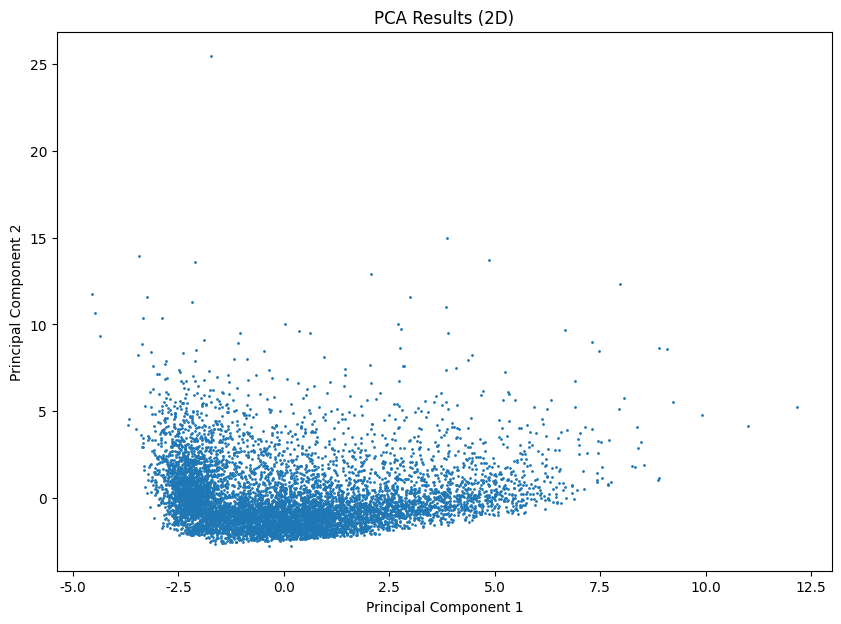

In [141]:
from sklearn.decomposition import PCA

X_pca = data.drop(columns=['CUST_ID'], errors='ignore')
X_pca = X_pca[[col for col in X_pca.columns if 'cluster' not in col.lower()]]
X_pca = X_pca.select_dtypes(include=['int64', 'float64'])

pca = PCA(n_components=2)
pca_transform = pca.fit_transform(X_pca)
pca_df = pd.DataFrame(pca_transform, columns=['Principal Component 1', 'Principal Component 2'])

plt.figure(figsize=(10,7))
plt.scatter(pca_df['Principal Component 1'],pca_df['Principal Component 2'], s=1)
plt.title('PCA Results (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 문제22: 적절한 주성분 수 결정
- 적절한 주성분 수를 결정하기 위해, 주성분의 설명력(분산 설명 비율)을 시각화하세요.

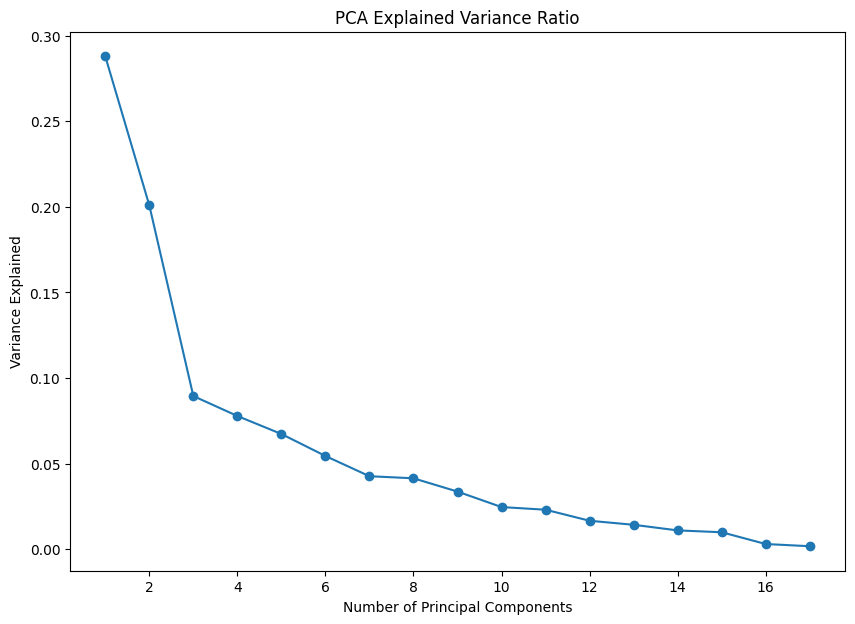

In [145]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_pca = data.drop(columns=['CUST_ID'], errors='ignore')
X_pca = X_pca[[col for col in X_pca.columns if 'cluster' not in col.lower()]]
X_pca = X_pca.select_dtypes(include=['int64', 'float64'])

pca = PCA()
pca.fit(X_pca)

explained_variance=pca.explained_variance_ratio_

plt.figure(figsize=(10, 7))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o'
)

plt.title('PCA Explained Variance Ratio')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')

plt.show()

### 문제23: 차원 축소를 활용한 데이터 시각화
- 적절한 주성분 수를 선택한 후, 이를 사용하여 데이터를 저차원으로 변환하세요.
- 시각화가 가능하다면, 데이터 시각화를 진행해주세요.

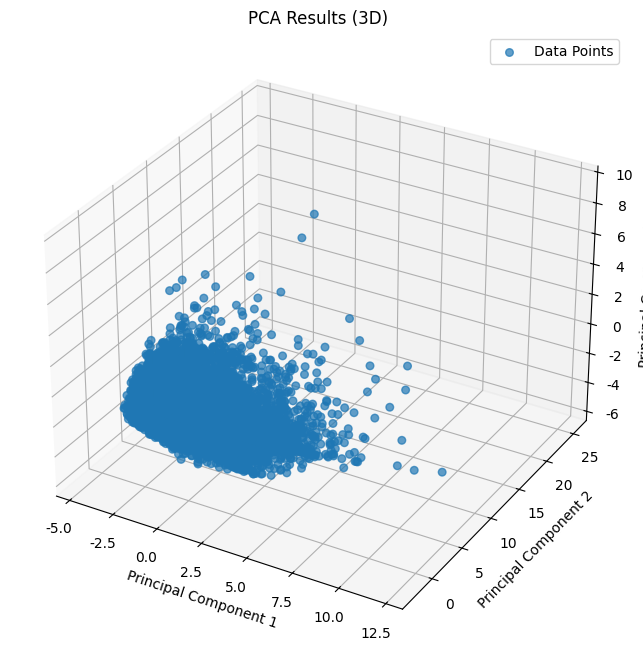

In [147]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

X_pca = data.drop(columns=['CUST_ID'], errors='ignore')
X_pca = X_pca[[col for col in X_pca.columns if 'cluster' not in col.lower()]]
X_pca = X_pca.select_dtypes(include=['int64', 'float64'])

pca = PCA(n_components=3)
pca_3d = pca.fit_transform(X_pca)

pca_3d_df = pd.DataFrame(
    pca_3d,
    columns=[
        'Principal Component 1',
        'Principal Component 2',
        'Principal Component 3'
    ]
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    pca_3d_df['Principal Component 1'],
    pca_3d_df['Principal Component 2'],
    pca_3d_df['Principal Component 3'],
    s=30,
    alpha=0.7,
    label='Data Points'
)

ax.set_title('PCA Results (3D)')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

ax.legend()

plt.show()

## PCA를 활용한 클러스터링 (6문제)


CUST_ID를 제외하면 분석 중인 데이터에 총 17개의 열이 있습니다. 차원이 너무 많아서 데이터의 분포나 특징을 시각화로 파악하는 것이 어렵네요. 관련하여, PCA를 통해 모든 차원의 특징을 최대한 살리면서, 동시에 데이터의 특징을 한눈에 파악할 수 있도록 2차원으로 차원을 축소해 봅시다.

### 문제24: PCA를 활용한 차원 축소 후 K-means 클러스터링
- PCA를 통해 차원 축소한 데이터를 사용하여 K-means 클러스터링을 수행하고 결과를 분석해보세요.
-  최적의 군집 개수를 Elbow plot를 통해 확인해보세요.


In [149]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

X= data.drop(columns=['CUST_ID'], errors='ignore')
X=X[[col for col in X.columns if 'cluster' not in col.lower()]]
X=X.select_dtypes(include=['int64','float64'])

pca=PCA(n_components=2)
pca_transform = pca.fit_transform(X)

pca_df =pd.DataFrame(
    pca_transform,
    columns=['PC1','PC2']
)
print("PC1 설명 분산 비율:", pca.explained_variance_ratio_[0])
print("PC2 설명 분산 비율:", pca.explained_variance_ratio_[1])
print("누적 설명 분산 비율:", pca.explained_variance_ratio_.sum())
pca_df.head()

PC1 설명 분산 비율: 0.28793138468071927
PC2 설명 분산 비율: 0.20088570293899713
누적 설명 분산 비율: 0.48881708761971643


,PC1,PC2
0,-1.794326,-1.521224
1,-2.039495,2.113771
2,1.223407,0.047507
3,-1.841440,-1.087497
4,0.914697,-0.807394


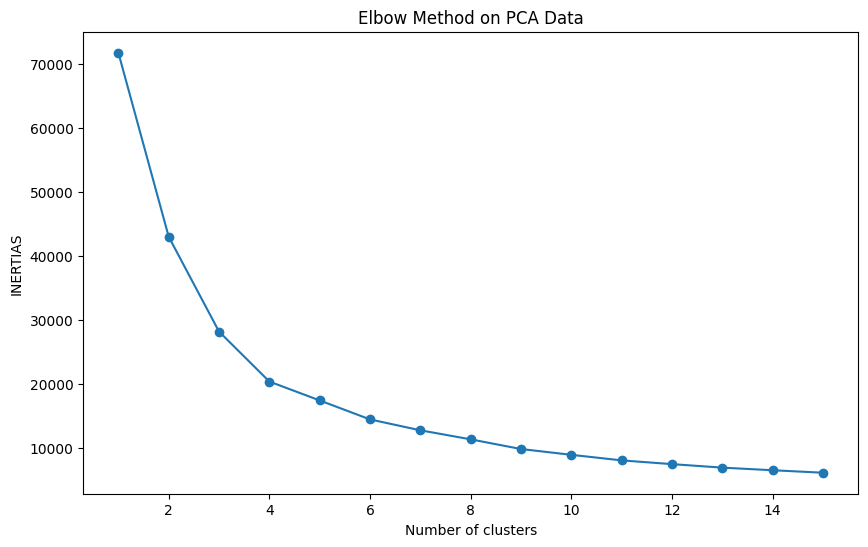

In [150]:
from sklearn.cluster import KMeans

inertias=[]

for k in range(1,16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(range(1,16),inertias,marker='o')
plt.title('Elbow Method on PCA Data')
plt.xlabel('Number of clusters')
plt.ylabel('INERTIAS')

plt.show()

### 문제25 : K-means 결과 해석하기
- 위 클러스터링 결과를 시각화해보세요.
- K-means의 결과를 해석해봅시다.

  - 각 클러스터별로 고객들은 어떤 특징을 가지나요?
  - 위 분석을 토대로 대출 서비스를 제안한다면, 어떤 전략이 좋을까요?

Cluster_PCA_KMeans
1    3283
3    3038
2    1262
0    1053
Name: count, dtype: int64


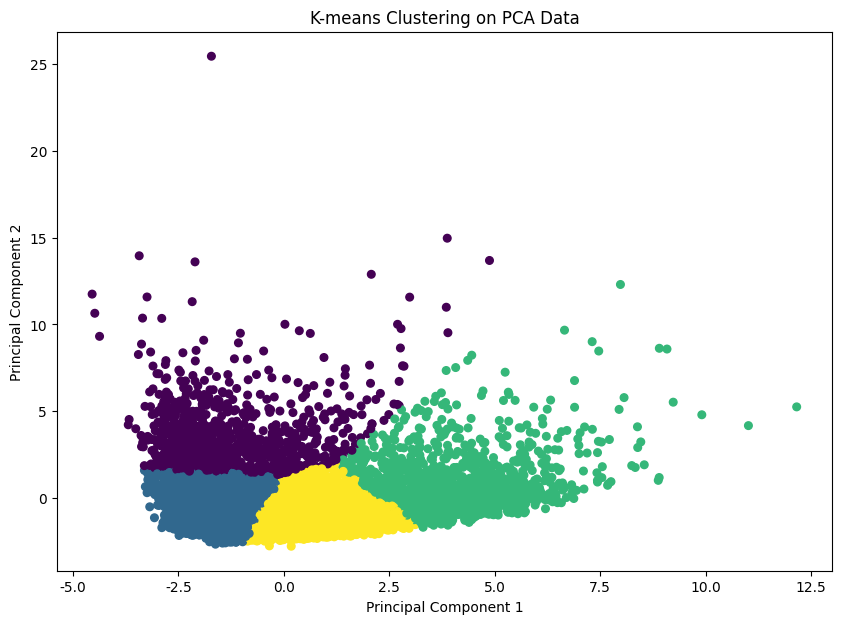

In [151]:
# Elbow plot 기준으로 클러스터 수 설정
optimal_k = 4

kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# PCA 데이터에 클러스터 결과 저장
pca_df['Cluster_PCA_KMeans'] = kmeans_pca.fit_predict(pca_df[['PC1', 'PC2']])

# 원본 data에도 결과 저장
data['Cluster_PCA_KMeans'] = pca_df['Cluster_PCA_KMeans']

# 클러스터별 개수 확인
print(data['Cluster_PCA_KMeans'].value_counts())

# PCA 2D 시각화
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster_PCA_KMeans'],
    cmap='viridis',
    s=30
)

plt.title('K-means Clustering on PCA Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

In [152]:
print("""
K-means 클러스터링 결과를 PCA 2차원 공간에서 시각화한 결과, 고객들은 크게 4개의 군집으로 구분되었다. PCA는 여러 금융 변수의 정보를 2개의 축으로 축소한 것이므로, x축과 y축은 각각 하나의 원본 변수가 아니라 BALANCE, PURCHASES, CREDIT_LIMIT, PAYMENTS, CASH_ADVANCE 등 여러 변수의 종합적인 특성을 반영한다.

먼저 오른쪽에 넓게 분포한 초록색 클러스터는 Principal Component 1 값이 높은 고객군이다. 이 군집은 전체적인 카드 이용 규모, 구매금액, 신용한도, 결제금액 등이 상대적으로 큰 고객군으로 해석할 수 있다. 따라서 카드 이용이 활발하고 금융 상품 활용 가능성이 높은 핵심 고객군으로 볼 수 있다.

왼쪽 위에 분포한 보라색 클러스터는 Principal Component 2 값이 높은 고객군이다. 이 고객군은 다른 고객에 비해 특정 금융 이용 패턴이 뚜렷하게 나타나는 집단으로 볼 수 있으며, 잔액 보유 수준이나 현금서비스 이용, 상환 부담 등이 상대적으로 클 가능성이 있다. 따라서 단순 마케팅 대상이라기보다는 리스크 관리와 상환 관리가 함께 필요한 고객군으로 해석할 수 있다.

왼쪽 아래에 분포한 파란색 클러스터는 PC1과 PC2 값이 모두 낮은 고객군이다. 이들은 전반적인 카드 이용 규모나 구매 활동이 낮은 고객군으로 볼 수 있다. 즉, 카드 사용 빈도와 금융 상품 이용도가 낮은 소극적 이용 고객군에 가깝다.

중앙 하단에 분포한 노란색 클러스터는 다른 군집에 비해 중간 수준의 특성을 보이는 고객군이다. 극단적으로 높은 이용 규모나 리스크를 보이지는 않지만, 일정 수준의 카드 사용과 결제 활동을 보이는 일반 고객군으로 해석할 수 있다.

이 분석을 바탕으로 대출 서비스를 제안한다면, 초록색 클러스터에는 신용한도 증액, 우대금리 대출, 프리미엄 금융상품 등 적극적인 금융 상품을 제안하는 전략이 적절하다. 이 고객군은 이용 규모가 크고 금융 상품 반응 가능성이 높기 때문이다.

노란색 클러스터에는 소액 신용대출, 생활비 대출, 단기 할부 금융과 같은 부담이 낮은 상품을 제안하는 것이 적절하다. 일반 고객군이므로 과도한 한도보다는 접근성이 높은 상품을 제공하는 전략이 효과적이다.

파란색 클러스터에는 대출 상품을 바로 제안하기보다는 카드 사용 활성화 혜택, 소액 한도 체험 상품, 무이자 할부 프로모션 등을 통해 금융 이용도를 높이는 전략이 적절하다. 이 고객군은 현재 이용 규모가 낮기 때문에 대출 전환 가능성을 단계적으로 높이는 접근이 필요하다.

보라색 클러스터는 잔액이나 현금서비스 이용 부담이 클 가능성이 있으므로, 신규 대출 확대보다는 기존 부채 관리, 대환대출, 이자 부담 완화 상품, 상환 계획 안내와 같은 리스크 관리형 대출 서비스를 제안하는 것이 적절하다.

종합하면, K-means 결과를 통해 고객을 단순히 하나의 집단으로 보는 것이 아니라 카드 이용 규모가 큰 우수 고객, 일반 이용 고객, 소극적 이용 고객, 리스크 관리가 필요한 고객으로 구분할 수 있었다. 따라서 대출 서비스 역시 모든 고객에게 동일하게 제안하기보다는 클러스터별 특성에 따라 차별화된 전략을 적용하는 것이 효과적이다.""")


K-means 클러스터링 결과를 PCA 2차원 공간에서 시각화한 결과, 고객들은 크게 4개의 군집으로 구분되었다. PCA는 여러 금융 변수의 정보를 2개의 축으로 축소한 것이므로, x축과 y축은 각각 하나의 원본 변수가 아니라 BALANCE, PURCHASES, CREDIT_LIMIT, PAYMENTS, CASH_ADVANCE 등 여러 변수의 종합적인 특성을 반영한다.

먼저 오른쪽에 넓게 분포한 초록색 클러스터는 Principal Component 1 값이 높은 고객군이다. 이 군집은 전체적인 카드 이용 규모, 구매금액, 신용한도, 결제금액 등이 상대적으로 큰 고객군으로 해석할 수 있다. 따라서 카드 이용이 활발하고 금융 상품 활용 가능성이 높은 핵심 고객군으로 볼 수 있다.

왼쪽 위에 분포한 보라색 클러스터는 Principal Component 2 값이 높은 고객군이다. 이 고객군은 다른 고객에 비해 특정 금융 이용 패턴이 뚜렷하게 나타나는 집단으로 볼 수 있으며, 잔액 보유 수준이나 현금서비스 이용, 상환 부담 등이 상대적으로 클 가능성이 있다. 따라서 단순 마케팅 대상이라기보다는 리스크 관리와 상환 관리가 함께 필요한 고객군으로 해석할 수 있다.

왼쪽 아래에 분포한 파란색 클러스터는 PC1과 PC2 값이 모두 낮은 고객군이다. 이들은 전반적인 카드 이용 규모나 구매 활동이 낮은 고객군으로 볼 수 있다. 즉, 카드 사용 빈도와 금융 상품 이용도가 낮은 소극적 이용 고객군에 가깝다.

중앙 하단에 분포한 노란색 클러스터는 다른 군집에 비해 중간 수준의 특성을 보이는 고객군이다. 극단적으로 높은 이용 규모나 리스크를 보이지는 않지만, 일정 수준의 카드 사용과 결제 활동을 보이는 일반 고객군으로 해석할 수 있다.

이 분석을 바탕으로 대출 서비스를 제안한다면, 초록색 클러스터에는 신용한도 증액, 우대금리 대출, 프리미엄 금융상품 등 적극적인 금융 상품을 제안하는 전략이 적절하다. 이 고객군은 이용 규모가 크고 금융 상품 반응 가능성이 높기 때문이다.

노

### 문제26 : PCA를 활용한 차원 축소 후 계층적 클러스터링
- PCA를 통해 차원 축소한 데이터를 사용하여 계층적 클러스터링을 수행하고 덴드로그램을 시각화하세요.

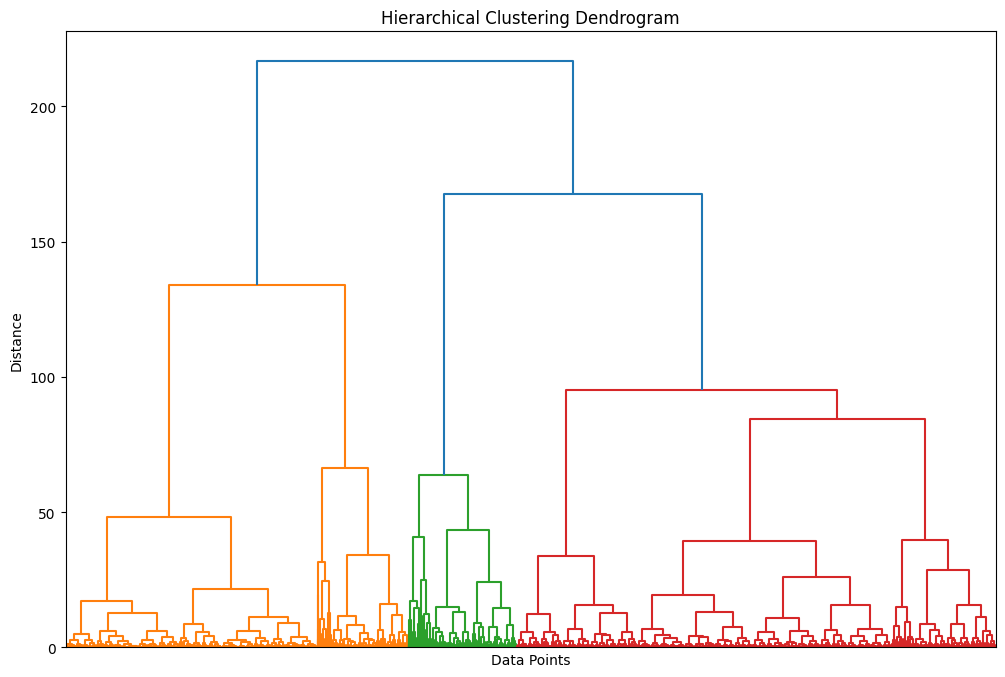

In [153]:
from scipy.cluster.hierarchy import dendrogram, linkage

pca_features = pca_df[['PC1','PC2']]
linked = linkage(pca_features,method='ward')

plt.figure(figsize=(12,8))
dendrogram(linked,no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

### 문제27 : PCA를 활용한 차원 축소 후 DBSCAN 클러스터링
- PCA를 통해 차원 축소한 데이터를 사용하여 DBSCAN 클러스터링을 수행하고 결과를 시각화하세요.

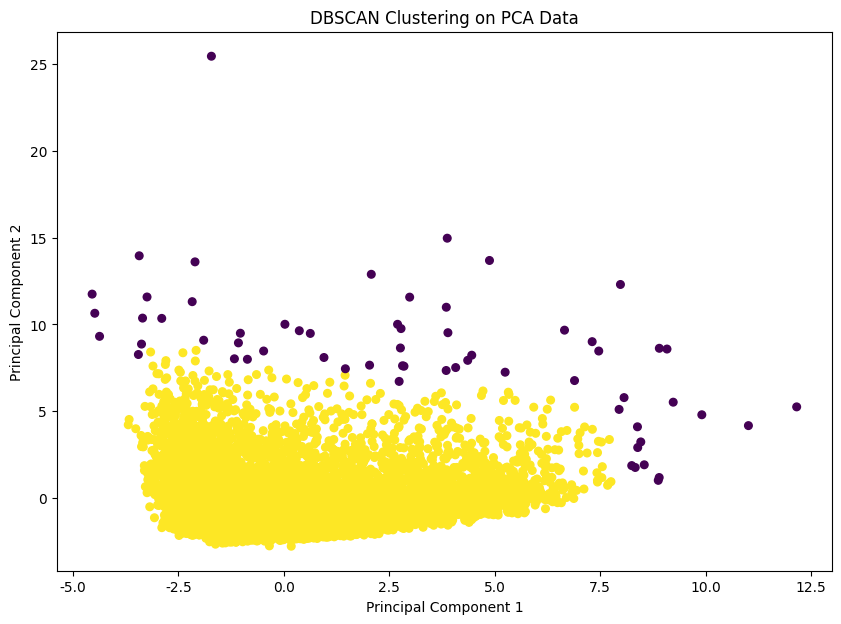

In [154]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

pca_features = pca_df[['PC1','PC2']]

dbscan_pca = DBSCAN(eps=0.7, min_samples=5)

pca_df['Cluster_PCA_DBSCAN'] = dbscan_pca.fit_predict(pca_features)
data['Cluster_PCA_DBSCAN'] = pca_df['Cluster_PCA_DBSCAN']

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster_PCA_DBSCAN'],
    cmap='viridis',
    s=30
)

plt.title('DBSCAN Clustering on PCA Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

### 문제28 : PCA를 활용한 차원 축소 후 GMM 클러스터링
- PCA를 통해 차원 축소한 데이터를 사용하여 GMM 클러스터링을 수행하고 결과를 시각화하세요.

Cluster_PCA_GMM
1    5346
2    1958
0    1332
Name: count, dtype: int64


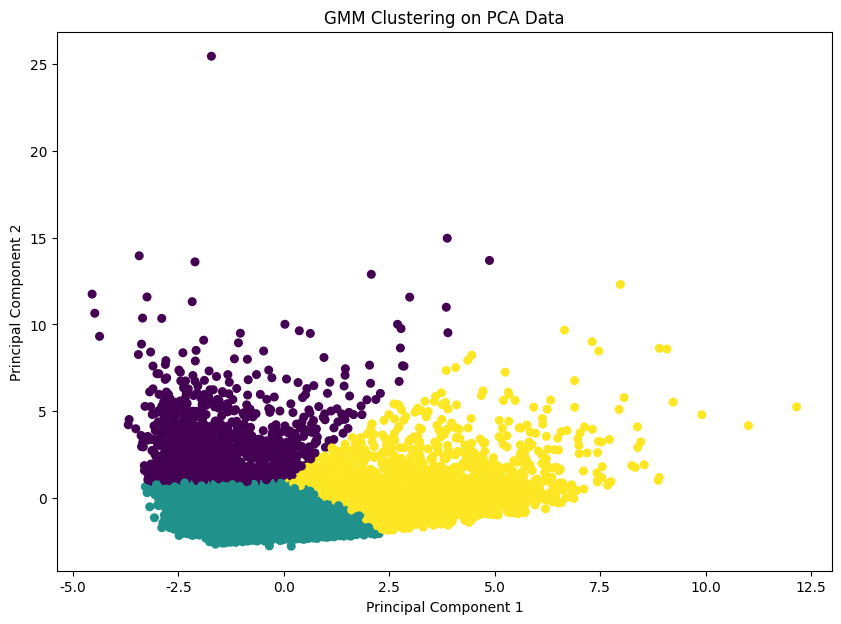

In [155]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

pca_features = pca_df[['PC1', 'PC2']]


gmm_pca = GaussianMixture(n_components=3, random_state=42)

pca_df['Cluster_PCA_GMM'] = gmm_pca.fit_predict(pca_features)
data['Cluster_PCA_GMM'] = pca_df['Cluster_PCA_GMM']


gmm_pca_prob = gmm_pca.predict_proba(pca_features)
pca_df['Cluster_PCA_GMM_Probability'] = gmm_pca_prob.max(axis=1)
data['Cluster_PCA_GMM_Probability'] = pca_df['Cluster_PCA_GMM_Probability']


print(data['Cluster_PCA_GMM'].value_counts())


plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster_PCA_GMM'],
    cmap='viridis',
    s=30
)

plt.title('GMM Clustering on PCA Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### 문제29 : 원본 데이터와 차원 축소 데이터를 사용한 클러스터링 결과 비교
- 원본 데이터와 차원 축소 데이터를 사용하여 다양한 클러스터링 기법을 적용한 결과를 비교해보세요.

In [ ]:
# 위에 분석한 내용을 바탕으로 자유롭게 의견을 작성해주세요.

In [156]:
print("""원본 데이터와 PCA 차원 축소 데이터를 활용하여 클러스터링 결과를 비교하였다. PCA를 적용한 데이터는 기존의 여러 수치형 변수를 Principal Component 1과 Principal Component 2라는 두 개의 축으로 압축한 데이터이다. 따라서 원본 데이터의 모든 정보를 완벽하게 보존하지는 않지만, 주요한 데이터 구조를 2차원 공간에서 직관적으로 확인할 수 있다는 장점이 있다.

먼저 GMM 클러스터링 결과를 보면 PCA 공간에서 데이터가 3개의 군집으로 비교적 명확하게 나뉘는 것을 확인할 수 있다. 왼쪽 상단, 왼쪽 하단, 오른쪽 영역으로 군집이 구분되며, 특히 오른쪽 영역의 고객군은 Principal Component 1 값이 높아 다른 고객군과 구분되는 특성을 보인다. GMM은 각 데이터가 특정 클러스터에 속할 확률을 기반으로 군집을 나누기 때문에, 군집 간 경계가 부드럽고 확률적인 해석이 가능하다는 장점이 있다. 따라서 고객이 어느 군집에 얼마나 확실하게 속하는지까지 함께 판단할 수 있다.

DBSCAN 결과에서는 대부분의 데이터가 하나의 큰 군집으로 분류되었고, 일부 멀리 떨어진 데이터들이 다른 색상으로 표시되었다. 이는 DBSCAN이 밀도 기반 알고리즘이기 때문에, 밀집된 대부분의 고객은 하나의 군집으로 묶고 밀도가 낮거나 주변과 동떨어진 고객은 별도로 구분했기 때문이다. 따라서 DBSCAN은 고객을 여러 개의 균형 잡힌 집단으로 나누는 데는 다소 한계가 있지만, 일반적인 고객 패턴에서 벗어난 이상 고객이나 특이 소비 패턴을 탐지하는 데 유용하다.

계층적 클러스터링 결과는 덴드로그램을 통해 데이터가 단계적으로 병합되는 구조를 보여준다. 시각화 결과, 큰 가지를 기준으로 보면 데이터가 몇 개의 주요 군집으로 나뉘는 흐름을 확인할 수 있다. 계층적 클러스터링은 K-means나 GMM처럼 처음부터 클러스터 수를 고정하지 않고, 데이터 간 거리와 병합 과정을 시각적으로 확인할 수 있다는 장점이 있다. 다만 데이터 수가 많을 경우 덴드로그램이 복잡해져 세부적인 해석이 어려울 수 있다.

종합적으로 보면, PCA를 적용한 클러스터링은 원본 데이터보다 시각적 해석이 훨씬 쉽다는 장점이 있다. 원본 데이터는 17개의 수치형 변수를 모두 사용하므로 고객의 세부 특성을 더 많이 반영할 수 있지만, 차원이 높아 결과를 직관적으로 이해하기 어렵다. 반면 PCA 데이터는 주요 정보를 2차원으로 압축하기 때문에 군집의 분포, 겹침 정도, 이상치 여부를 한눈에 파악할 수 있다.

알고리즘별로 보면, GMM은 PCA 공간에서 군집을 비교적 명확하게 나누고 확률 기반 해석이 가능하다는 점에서 고객 세분화에 유용하다. DBSCAN은 다수의 고객을 하나의 밀집 군집으로 묶고 일부 특이한 고객을 구분하므로, 이상치 또는 특이 고객 탐지에 적합하다. 계층적 클러스터링은 전체 고객 데이터가 어떤 구조로 병합되는지 확인하는 데 유용하지만, 대규모 데이터에서는 해석이 복잡해질 수 있다.

따라서 실무적으로는 원본 데이터 기반 클러스터링을 통해 고객의 세부 특성을 분석하고, PCA 기반 시각화를 통해 군집 구조를 설명하는 방식이 가장 적절하다. 고객 세분화와 마케팅 전략 수립에는 GMM이나 K-means가 적합하고, 특이 고객 탐지에는 DBSCAN, 전체 군집 구조 파악에는 계층적 클러스터링을 보조적으로 활용할 수 있다.""")

원본 데이터와 PCA 차원 축소 데이터를 활용하여 클러스터링 결과를 비교하였다. PCA를 적용한 데이터는 기존의 여러 수치형 변수를 Principal Component 1과 Principal Component 2라는 두 개의 축으로 압축한 데이터이다. 따라서 원본 데이터의 모든 정보를 완벽하게 보존하지는 않지만, 주요한 데이터 구조를 2차원 공간에서 직관적으로 확인할 수 있다는 장점이 있다.

먼저 GMM 클러스터링 결과를 보면 PCA 공간에서 데이터가 3개의 군집으로 비교적 명확하게 나뉘는 것을 확인할 수 있다. 왼쪽 상단, 왼쪽 하단, 오른쪽 영역으로 군집이 구분되며, 특히 오른쪽 영역의 고객군은 Principal Component 1 값이 높아 다른 고객군과 구분되는 특성을 보인다. GMM은 각 데이터가 특정 클러스터에 속할 확률을 기반으로 군집을 나누기 때문에, 군집 간 경계가 부드럽고 확률적인 해석이 가능하다는 장점이 있다. 따라서 고객이 어느 군집에 얼마나 확실하게 속하는지까지 함께 판단할 수 있다.

DBSCAN 결과에서는 대부분의 데이터가 하나의 큰 군집으로 분류되었고, 일부 멀리 떨어진 데이터들이 다른 색상으로 표시되었다. 이는 DBSCAN이 밀도 기반 알고리즘이기 때문에, 밀집된 대부분의 고객은 하나의 군집으로 묶고 밀도가 낮거나 주변과 동떨어진 고객은 별도로 구분했기 때문이다. 따라서 DBSCAN은 고객을 여러 개의 균형 잡힌 집단으로 나누는 데는 다소 한계가 있지만, 일반적인 고객 패턴에서 벗어난 이상 고객이나 특이 소비 패턴을 탐지하는 데 유용하다.

계층적 클러스터링 결과는 덴드로그램을 통해 데이터가 단계적으로 병합되는 구조를 보여준다. 시각화 결과, 큰 가지를 기준으로 보면 데이터가 몇 개의 주요 군집으로 나뉘는 흐름을 확인할 수 있다. 계층적 클러스터링은 K-means나 GMM처럼 처음부터 클러스터 수를 고정하지 않고, 데이터 간 거리와 병합 과정을 시각적으로 확인할 수 있다는 장점이 있다. 다만 데이터 수가 많을 경우 덴드로그램이